# 02 · How faithful are the SAEs?

In [1]:
import sys, json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir() and (p / "results").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import *

P = paths(ROOT)
FIG = P["figures"]
B, SEED = bootstrap_settings(ROOT)
set_style()
pd.set_option("display.precision", 3)

In [2]:
geo = pd.concat([pd.read_csv(P["sae"] / c / l / "geometry.csv") for c in CORPORA for l in HOOK_ORDER
                 if (P["sae"] / c / l / "geometry.csv").exists()], ignore_index=True)
beh = []
for c in CORPORA:
    for l in HOOK_ORDER:
        f = P["sae"] / c / l / "behavior.csv"
        if not f.exists():
            continue
        b = pd.read_csv(f); w = b.n_scored_tokens.to_numpy(float)
        avg = lambda col: float(np.average(b[col], weights=w))
        o, z = avg("original_nll_bits"), avg("zero_preserve_window_start_nll_bits")
        r = avg("reconstruction_preserve_window_start_nll_bits")
        beh.append(dict(corpus=c, label=l, added_nll=r - o, kl=avg("reconstruction_preserve_window_start_kl_bits"),
                        loss_recovered=(z - r) / (z - o) if z - o > 1e-8 else np.nan))
beh = pd.DataFrame(beh)
x = np.arange(len(HOOK_ORDER))

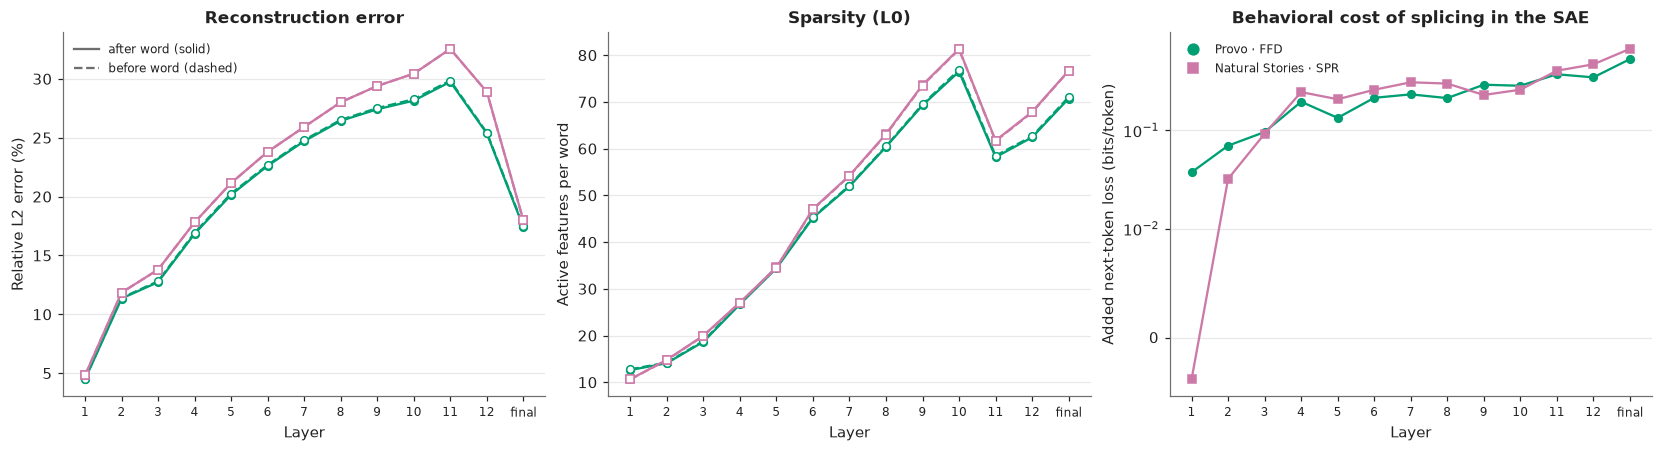

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")
for c in CORPORA:
    for kind, group, ls, mfc in [("post", "all", "-", None), ("prefix", "text_token", "--", "white")]:
        g = geo[(geo.corpus == c) & (geo.kind == kind) & (geo.group == group)].set_index("label").reindex(HOOK_ORDER)
        kw = dict(color=CORPUS_COLORS[c], ls=ls, marker=CORPUS_MARKERS[c], ms=5, mfc=mfc or CORPUS_COLORS[c])
        axes[0].plot(x, 100 * g.mean_relative_l2_error, **kw)
        axes[1].plot(x, g.mean_active, **kw)
    g = beh[beh.corpus == c].set_index("label").reindex(HOOK_ORDER)
    axes[2].plot(x, g.added_nll, color=CORPUS_COLORS[c], marker=CORPUS_MARKERS[c], ms=5, label=CORPUS_LABELS[c])
axes[0].set(ylabel="Relative L2 error (%)", title="Reconstruction error")
axes[1].set(ylabel="Active features per word", title="Sparsity (L0)")
axes[2].set(ylabel="Added next-token loss (bits/token)", title="Behavioral cost of splicing in the SAE")
axes[2].set_yscale("symlog", linthresh=0.01)
for ax in axes:
    ax.set_xticks(x, HOOK_TICKS, fontsize=8); ax.set_xlabel("Layer"); ax.grid(axis="y", color=GRID)
axes[0].plot([], [], color=MUTED, ls="-", label="after word (solid)")
axes[0].plot([], [], color=MUTED, ls="--", label="before word (dashed)")
axes[0].legend(fontsize=8); corpus_legend(axes[2], fontsize=8)
save_figure(fig, FIG, "02_sae_fidelity"); plt.show()

In [4]:
beh.assign(Corpus=beh.corpus.map(CORPUS_LABELS)).pivot(index="label", columns="Corpus",
          values=["added_nll", "loss_recovered"]).reindex(HOOK_ORDER).round(3)

added_nll                    loss_recovered  \
Corpus           Natural Stories · SPR Provo · FFD Natural Stories · SPR   
label                                                                      
L01                             -0.004       0.038                 1.000   
L02                              0.032       0.070                 0.995   
L03                              0.093       0.096                 0.986   
L04                              0.246       0.196                 0.985   
L05                              0.208       0.135                 0.982   
L06                              0.260       0.215                 0.980   
L07                              0.310       0.233                 0.972   
L08                              0.301       0.214                 0.976   
L09                              0.230       0.293                 0.978   
L10                              0.260       0.286                 0.982   
L11                              0.406       0.374                 0.964   
L12                              0.472       0.348                 0.950   
final_resid_post                 0.679       0.533                 0.897   

                              
Corpus           Provo · FFD  
label                         
L01                    0.997  
L02                    0.988  
L03                    0.984  
L04                    0.985  
L05                    0.988  
L06                    0.984  
L07                    0.975  
L08                    0.986  
L09                    0.971  
L10                    0.980  
L11                    0.966  
L12                    0.961  
final_resid_post       0.909